# Tutorial 4: Sky Localisation & Fisher-Matrix Analysis with GWFish

This notebook extends **Tutorial 3** (SNR-only detection efficiency) by running the
full **Fisher-matrix** analysis via `compute_network_errors`.  In addition to the
network SNR we obtain:

- **Parameter estimation errors** (masses, distance, inclination, …)
- **90 % credible sky-localisation area** $\Delta\Omega$

We loop over several detector-network configurations and compare detection rates
and sky-localisation distributions.

---

## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2
import notebook_setup

import os
os.environ["OMP_NUM_THREADS"] = "1"   # avoid thread over-subscription
os.environ["MKL_NUM_THREADS"] = "1"

import multiprocessing as mp
cpus = mp.cpu_count()

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import GWFish.modules    as gw
from   GWFish.modules.fishermatrix import compute_network_errors, sky_localization_percentile_factor
from   joblib            import Parallel, delayed
from   astropy.cosmology import Planck18
from   pathlib           import Path

#plt.style.use('../configurations/style.mplstyle')

datafiles  = Path("../datafiles")
output_dir = Path("Output_files/tutorial4_gwfish_skyloc")
output_dir.mkdir(parents=True, exist_ok=True)

## 1. Build a Synthetic Population in Redshift

> We no longer load a precomputed catalogue.

We generate events in redshift bins from `1e-2` to `1.0` (10 bins, 20 events per bin), sample isotropic viewing angles via

> `u ~ U(0, 1), theta_v = arccos(1 - u)`

and keep only events with `theta_v < 15 deg`. For this tutorial we set a fixed `E_iso = 1.5e51 erg` for all events.

In [2]:
rng = np.random.default_rng(42)

z_min, z_max    = 0.01, 2
n_bins          = 30
events_per_bin  = 1000  # EXACTLY 50 events per bin after theta_v cut
E_ISO_FIXED     = 1.5e51
theta_cut_deg   = 15.0

z_base_vals = np.logspace(np.log10(z_min), np.log10(z_max), n_bins + 1)
total_events = n_bins * events_per_bin
# repeat the redshift base vals n_times to get the total number of events
redshift_all = np.repeat(z_base_vals[:-1], events_per_bin) 


# Isotropic viewing-angle sampling PRE-restricted to theta_v < 15 deg
theta_cut_rad = np.radians(theta_cut_deg)
u_max = 1.0 - np.cos(theta_cut_rad)

# u ~ U(0, u_max) ensures theta_v < 15
u = rng.uniform(0.0, u_max, size=redshift_all.size)
theta_v_rad_all = np.arccos(1.0 - u)
theta_v_deg_all = np.degrees(theta_v_rad_all)

population = pd.DataFrame({
    "z": redshift_all,
    "theta_v": theta_v_deg_all,
    "theta_v_rad": theta_v_rad_all,
    "E_iso": np.full(redshift_all.size, E_ISO_FIXED),
})

print(f"Generated exactly {len(population)} events across {n_bins} bins.")
print(f"Events with theta_v < {theta_cut_deg:.1f} deg: {len(population)}")
print(f"Redshift range: [{population['z'].min():.3f}, {population['z'].max():.3f}]")
population.head()

Generated exactly 30000 events across 30 bins.
Events with theta_v < 15.0 deg: 30000
Redshift range: [0.010, 1.676]


,z,theta_v,theta_v_rad,E_iso
0,0.01,13.187653,0.230168,1.500000e+51
1,0.01,9.921221,0.173158,1.500000e+51
2,0.01,13.893439,0.242486,1.500000e+51
3,0.01,12.515410,0.218435,1.500000e+51
4,0.01,4.591343,0.080134,1.500000e+51


## 2. Generate BNS Parameters

We assign random extrinsic parameters for sky-localisation studies and use source-frame masses drawn from a Gaussian distribution.

The sample is built from the filtered synthetic population (`theta_v < 15 deg`).

In [3]:
n_ev = len(population)

redshift = population["z"].to_numpy()
theta_jn = population["theta_v_rad"].to_numpy()

# BNS masses — Gaussian (Galactic DNS population)
m1, m2 = rng.normal(1.33, 0.09, (n_ev, 2)).T
mass_1 = np.maximum(m1, m2)
mass_2 = np.minimum(m1, m2)

params_dict = {
    "mass_1_source"         : mass_1,
    "mass_2_source"         : mass_2,
    "redshift"              : redshift,
    "luminosity_distance"   : Planck18.luminosity_distance(redshift).value,
    "theta_jn"              : theta_jn,
    "ra"                    : np.random.uniform(0.0, 2 * np.pi, n_ev),
    "dec"                   : np.arcsin(np.random.uniform(-1.0, 1.0, n_ev)),
    "psi"                   : np.random.uniform(0.0, np.pi, n_ev),
    "phase"                 : np.random.uniform(0.0, 2 * np.pi, n_ev),
    "geocent_time"          : np.random.uniform(1577491218, 1609027217, n_ev),
    "a_1"                   : np.zeros(n_ev),
    "a_2"                   : np.zeros(n_ev),
}

df_params = pd.DataFrame(params_dict)
#df_params["E_iso"] = E_ISO_FIXED
#df_params["theta_v_deg"] = np.degrees(theta_jn)

df_params.to_csv(output_dir / "synthetic_bns_params.csv", index=False)
population.to_csv(output_dir / "synthetic_population_theta_lt15.csv", index=False)

print(f"Generated {n_ev} BNS parameter sets")
print(f"<m1> = {mass_1.mean():.3f} Msun, <m2> = {mass_2.mean():.3f} Msun")
print(f"z range = [{redshift.min():.3f}, {redshift.max():.3f}]")
df_params.head()

Generated 30000 BNS parameter sets
<m1> = 1.380 Msun, <m2> = 1.278 Msun
z range = [0.010, 1.676]


,mass_1_source,mass_2_source,redshift,luminosity_distance,theta_jn,ra,dec,psi,phase,geocent_time,a_1,a_2
0,1.253872,1.159179,0.01,44.647106,0.230168,0.161040,0.045677,1.392879,5.565482,1.591037e+09,0.0,0.0
1,1.269674,1.240519,0.01,44.647106,0.173158,0.244112,0.896224,0.304984,4.864090,1.591969e+09,0.0,0.0
2,1.378693,1.356990,0.01,44.647106,0.242486,5.318390,-1.303016,0.990908,6.135119,1.605020e+09,0.0,0.0
3,1.258930,1.239387,0.01,44.647106,0.218435,1.101456,-0.347181,0.427417,1.314563,1.585900e+09,0.0,0.0
4,1.483476,1.427516,0.01,44.647106,0.080134,1.526851,0.651568,1.144658,1.157103,1.588213e+09,0.0,0.0


## 3. Resolve Detector Configuration

We use the same portable YAML approach from Tutorial 3: bare PSD filenames in
`configs/coba.yaml` are resolved to absolute paths under `psds/` at runtime.

In [4]:
import re, tempfile

yaml_template = Path("configs/coba.yaml")
psd_dir       = Path("psds").resolve()

def resolve_psd_paths(yaml_path, psd_dir):
    """Resolve bare psd_data filenames in a GWFish YAML to absolute paths."""
    text = yaml_path.read_text()
    def _resolve(m):
        fname = m.group(1).strip()
        if fname.startswith("/"):
            return m.group(0)
        resolved = (psd_dir / fname).resolve()
        if not resolved.exists():
            raise FileNotFoundError(
                f"PSD file not found: {resolved}  (referenced in {yaml_path})"
            )
        return f"psd_data:{m.group(0).split('psd_data:')[1].replace(fname, str(resolved))}"
    resolved_text = re.sub(r"psd_data:\s*(.+)", _resolve, text)
    tmp = tempfile.NamedTemporaryFile(
        mode="w", suffix=".yaml", prefix="gwfish_conf_", delete=False
    )
    tmp.write(resolved_text)
    tmp.flush()
    return Path(tmp.name)

conf_file = resolve_psd_paths(yaml_template, psd_dir)
print(f"Resolved config written to: {conf_file}")

Resolved config written to: /tmp/gwfish_conf_q36x78rk.yaml


## 4. Define Detector Combinations

We test several network configurations — from current-generation (2G) detectors
to full 3G networks with Cosmic Explorer.

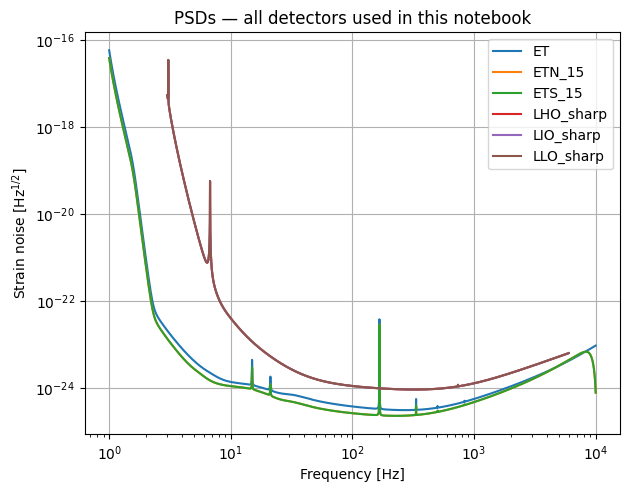

Combinations to analyse: ['3G_2L', '3G_delta', 'A*']


In [5]:
combinations = {
    "3G_2L"         : ["ETS_15", "ETN_15"],
    "3G_delta"      : ["ET"],
    "A*"            : ["LLO_sharp", "LHO_sharp", "LIO_sharp"]
}

waveform_model = "IMRPhenomD_NRTidalv2"
SNR_THRESHOLD  = 8.0

# Quick PSD sanity check — plot all unique detectors
all_det_names = sorted({d for dets in combinations.values() for d in dets})
all_network   = gw.detection.Network(detector_ids=all_det_names, config=conf_file)
for det in all_network.detectors:
    det.components[0].plot_psd()
plt.legend(all_det_names)
plt.title("PSDs — all detectors used in this notebook")
plt.savefig(output_dir / "all_PSDs.pdf")
plt.show()

print(f"Combinations to analyse: {list(combinations.keys())}")

## 5. Run Fisher-Matrix Analysis (All Combinations)

For each detector network we run `compute_network_errors` in parallel using
`functools.partial` + `pool.map`. This returns:

- **SNR** per detector + network
- **Parameter errors** from the Fisher matrix
- **Sky-localisation area** (converted to deg² at 90 % credibility)

In [10]:
df_params[:100]

,mass_1_source,mass_2_source,redshift,luminosity_distance,theta_jn,ra,dec,psi,phase,geocent_time,a_1,a_2
0,1.253872,1.159179,0.01,44.647106,0.230168,0.161040,0.045677,1.392879,5.565482,1.591037e+09,0.0,0.0
1,1.269674,1.240519,0.01,44.647106,0.173158,0.244112,0.896224,0.304984,4.864090,1.591969e+09,0.0,0.0
2,1.378693,1.356990,0.01,44.647106,0.242486,5.318390,-1.303016,0.990908,6.135119,1.605020e+09,0.0,0.0
3,1.258930,1.239387,0.01,44.647106,0.218435,1.101456,-0.347181,0.427417,1.314563,1.585900e+09,0.0,0.0
4,1.483476,1.427516,0.01,44.647106,0.080134,1.526851,0.651568,1.144658,1.157103,1.588213e+09,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.419882,1.302046,0.01,44.647106,0.207623,1.741197,0.164253,1.390465,4.463429,1.581289e+09,0.0,0.0
96,1.492387,1.298143,0.01,44.647106,0.157187,1.298074,0.571095,1.993060,6.130440,1.580836e+09,0.0,0.0
97,1.371578,1.369085,0.01,44.647106,0.077306,3.520492,0.562638,2.551531,3.363097,1.584011e+09,0.0,0.0
98,1.320056,1.210258,0.01,44.647106,0.089707,0.654817,-0.267577,1.326110,0.738674,1.585261e+09,0.0,0.0


In [ ]:
results_all  = {}
my_pop_split = np.array_split(df_params, cpus)

for combo_name, det_names in combinations.items():
    print(f"\n{'='*60}")
    print(f"  {combo_name}  →  {det_names}")
    print(f"{'='*60}")

    network = gw.detection.Network(
        detector_ids  = det_names,
        config        = conf_file,
        detection_SNR = (0, SNR_THRESHOLD),
    )

    # ---- joblib parallelisation (much faster than mp.Pool for GWFish) ----
    def run_fisher(chunk_df):
        return compute_network_errors(
            network          = network,
            parameter_values = chunk_df,
            waveform_model   = waveform_model,
        )

    chunks = Parallel(n_jobs=cpus, verbose=10)(
        delayed(run_fisher)(chunk) for chunk in my_pop_split
    )

    # Unpack: each chunk returns (detected, snr, errors, sky_loc)
    _, snr_chunks, errors_chunks, skyloc_chunks = zip(*chunks)

    # compute_network_errors returns 1D SNR (network SNR per event)
    snr_array    = np.concatenate(snr_chunks)
    errors_array = np.concatenate(errors_chunks)
    skyloc_raw   = (np.concatenate(skyloc_chunks)
                    if skyloc_chunks[0] is not None else None)

    # Convert sky localisation to 90 % credible area in deg²
    skyloc_deg2 = (skyloc_raw * sky_localization_percentile_factor()
                   if skyloc_raw is not None else None)

    network_snr  = snr_array
    detected     = network_snr >= SNR_THRESHOLD
    n_det        = int(detected.sum())

    print(f"  Detected {n_det} / {len(network_snr)}  "
          f"({n_det / len(network_snr) * 100:.1f} %)")

    results_all[combo_name] = {
        "det_names"  : det_names,
        "snr"        : snr_array,
        "errors"     : errors_array,
        "skyloc_deg2": skyloc_deg2,
        "detected"   : detected,
    }


  3G_2L  →  ['ETS_15', 'ETN_15']


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
  2%|▏         | 42/2500 [00:13<12:47,  3.20it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:
import time
import numpy as np
from joblib import Parallel, delayed


def benchmark_parallel_scaling(
    df_params, network, waveform_model, max_cpus
):
    """Benchmarks the Parallel execution time across different CPU counts.

    Parameters:
    -----------
    df_params : pandas.DataFrame
        The full parameter dataframe.
    network : gw.detection.Network
        The initialized network object.
    waveform_model : str
        The active waveform model identifier.
    max_cpus : int
        The maximum number of cores to test.

    Returns:
    --------
    dict
        A dictionary mapping CPU counts to execution times in seconds.
    """
    df_reduced = df_params.iloc[:1000]
    timing_results = {}

    def run_fisher(chunk_df):
        return compute_network_errors(
            network=network,
            parameter_values=chunk_df,
            waveform_model=waveform_model,
        )

    for cpus in range(2, max_cpus + 1):
        my_pop_split = np.array_split(df_reduced, cpus)

        start_time = time.perf_counter()
        _ = Parallel(n_jobs=cpus, verbose=0)(
            delayed(run_fisher)(chunk) for chunk in my_pop_split
        )
        elapsed_time = time.perf_counter() - start_time

        timing_results[cpus] = elapsed_time

    return timing_results
network_test = gw.detection.Network(
    detector_ids  = ["LLO_sharp"],
    config        = conf_file,
    detection_SNR = (0, SNR_THRESHOLD),
)
timing_results = benchmark_parallel_scaling(
    df_params=df_params,
    network=network_test,
    waveform_model=waveform_model,
    max_cpus=cpus,
)

100%|██████████| 84/84 [00:42<00:00,  2.00it/s]


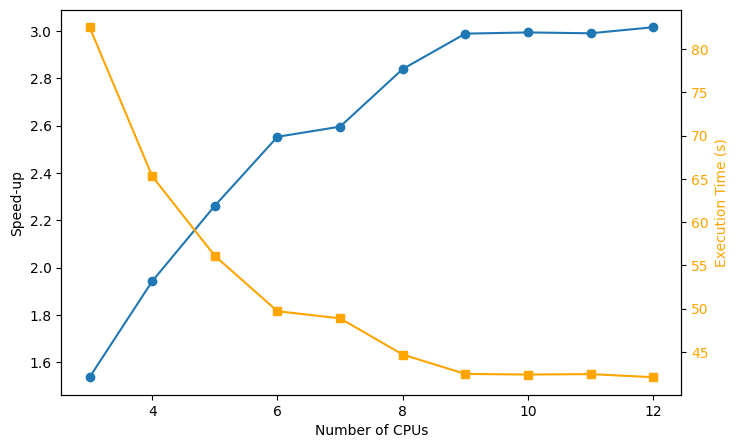

In [17]:
cpus_axis = np.arange(2, cpus + 1)
timing_results_axis = np.array([timing_results[c] for c in cpus_axis])
speed_up = timing_results_axis[0] / timing_results_axis
#plt.figure(figsize=(8, 5))
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(cpus_axis[1:], speed_up[1:], marker='o')
ax.set_xlabel("Number of CPUs")
ax.set_ylabel("Speed-up")

ax2 = ax.twinx()
ax2.plot(cpus_axis[1:], timing_results_axis[1:], marker='s', color='orange')
ax2.set_ylabel("Execution Time (s)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
plt.show()

In [ ]:
# add the remaining entries
df_params["E_iso"] = E_ISO_FIXED
df_params["theta_v_deg"] = np.degrees (theta_jn)

# output the results to CSV for later analysis
for combo_name, res in results_all.items():
    # add redshift, theta_v_rad, E_iso
    df_results = pd.DataFrame({
        "combo_name": combo_name,
        "det_names": [",".join(res["det_names"])] * len(df_params),
        "snr": res["snr"],
        "skyloc_deg2": res["skyloc_deg2"],
        "detected": res["detected"],
    })
    df_results["redshift"] = df_params["redshift"]
    df_results["theta_v_rad"] = df_params["theta_v_deg"]
    df_results["E_iso"] = df_params["E_iso"]

    df_results.to_csv(output_dir / f"results_{combo_name}.csv", index=False)

Text(0.5, 1.0, 'Detection chance vs redshift')

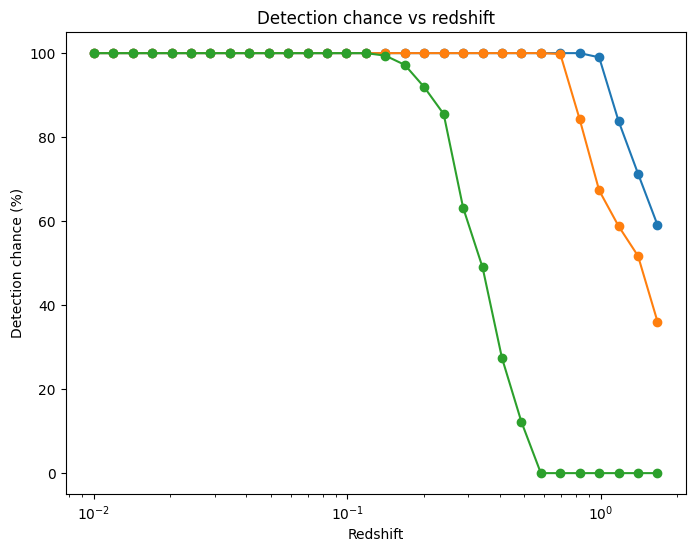

In [ ]:
# new statistic, % detection chance as a function of redshift (per bin)
detection_rates = {}
for combo_name, results in results_all.items():
    det = results["detected"]
    z = df_params["redshift"].to_numpy()
    rates = []
    for i in range(n_bins):
        in_bin = (z >= z_base_vals[i]) & (z < z_base_vals[i + 1])
        if in_bin.sum() > 0:
            rate = det[in_bin].mean() * 100  # % detection chance in this bin
        else:
            rate = np.nan
        rates.append(rate)
    detection_rates[combo_name] = rates


plt.figure(figsize=(8, 6))
for combo_name, rates in detection_rates.items():
    plt.plot(z_base_vals[:-1], rates, marker="o", label=combo_name)
plt.xscale("log")
plt.xlabel("Redshift")
plt.ylabel("Detection chance (%)")
plt.title("Detection chance vs redshift")

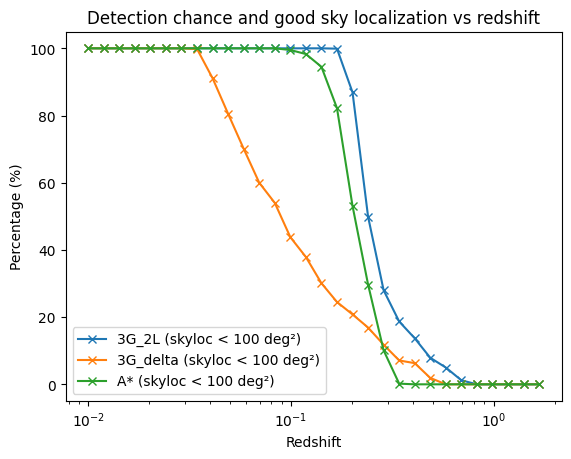

In [ ]:
# plot % of detected that have sky localization better than 100 deg^2 (ie. less than)
threshold = 100 # deg^2

for combo_name, res in results_all.items():
    det = res["detected"]
    skyloc = res["skyloc_deg2"]
    if skyloc is not None:
        good_skyloc = (skyloc < threshold) & det
        rates = []
        for i in range(n_bins):
            in_bin = (df_params["redshift"] >= z_base_vals[i]) & (df_params["redshift"] < z_base_vals[i + 1])
            if in_bin.sum() > 0:
                rate = good_skyloc[in_bin].mean() * 100  # % with good sky loc among detected in this bin
            else:
                rate = np.nan
            rates.append(rate)
        plt.plot(z_base_vals[:-1], rates, marker="x", label=f"{combo_name} (skyloc < {threshold} deg²)")

plt.xlabel("Redshift")
plt.ylabel("Percentage (%)")
#plt.title("Detection chance and good sky localization vs redshift")
plt.legend()
plt.xscale("log")
plt.savefig(output_dir / "detection_and_skyloc_vs_redshift.pdf")
plt.show()

Saved paper-ready plot to: Output_files/tutorial4_gwfish_skyloc/paper_plot_skyloc_fraction_linear.pdf


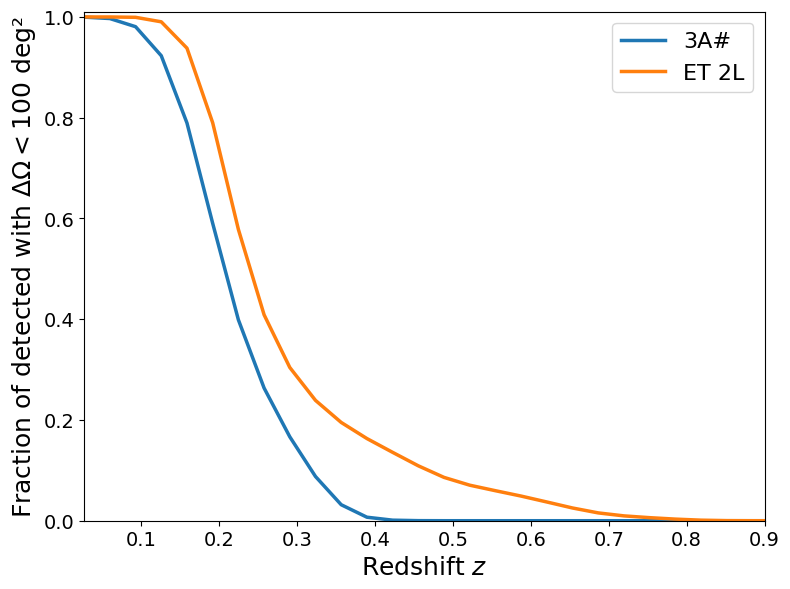

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

# Set up paths and target combinations
output_dir = Path("Output_files/tutorial4_gwfish_skyloc")
combos_to_plot = {"A*": "3A#", "3G_2L": "ET 2L"}
threshold = 100 # deg^2

# Linear redshift bins up to z=1
z_max_plot = 1.0
n_bins_plot = 30
z_edges = np.linspace(0.01, z_max_plot, n_bins_plot + 1)
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

plt.figure(figsize=(8, 6))
FS = 18

for combo_name, new_label in combos_to_plot.items():
    # Load the results dataframe without rerunning the main pipeline
    try:
        df = pd.read_csv(output_dir / f"results_{combo_name}.csv")
    except FileNotFoundError:
        print(f"Could not find results_{combo_name}.csv. Please ensure it was generated.")
        continue
        
    det = df["detected"].astype(bool)
    skyloc = df["skyloc_deg2"]
    
    # Detected & good sky localisation
    good_skyloc = (skyloc < threshold) & det
    
    rates = []
    for i in range(n_bins_plot):
        in_bin = (df["redshift"] >= z_edges[i]) & (df["redshift"] < z_edges[i + 1])
        
        # We calculate the % of *detected* events that have a good sky localisation
        det_in_bin = det[in_bin].sum()
        if det_in_bin > 0:
            rate = (good_skyloc[in_bin].sum() / det_in_bin) * 100
        else:
            rate = np.nan
        rates.append(rate)
        
    # Apply a tiny bit of smoothing (sigma=1.0)
    # Mask NaNs for the filter, but we'll restore them if needed
    rates_array = np.array(rates)
    valid_mask = ~np.isnan(rates_array)
    rates_filled = np.interp(np.arange(len(rates_array)), np.arange(len(rates_array))[valid_mask], rates_array[valid_mask])
    rates_smoothed = gaussian_filter1d(rates_filled, sigma=1.0)
    
    plt.plot(z_centers, rates_smoothed/100, linewidth=2.5, label=f"{new_label}")

# Paper-ready styling properties
plt.xlabel("Redshift $z$", fontsize=FS)
plt.ylabel(f"Fraction of detected with $\\Delta\\Omega < {threshold}$ deg²", fontsize=FS)
plt.xlim(min(z_centers), 0.9)
plt.ylim(0, 1.01)
#plt.grid(True, alpha=0.3, linestyle="--")
plt.tick_params(axis='both', which='major', labelsize=FS-4)
plt.legend(fontsize=FS-2, loc="upper right")

plt.tight_layout()
plt.savefig(output_dir / "paper_plot_skyloc_fraction_linear.pdf", dpi=300, bbox_inches="tight")
print(f"Saved paper-ready plot to: {output_dir / 'paper_plot_skyloc_fraction_linear.pdf'}")
plt.show()

## 6. Detection Rate Summary

In [ ]:
print(f"{'Combination':<25s}  {'Detected':>8s}  {'Total':>6s}  {'Rate':>7s}  {'±σ':>7s}")
print("-" * 60)

for combo_name, res in results_all.items():
    n_tot = len(res["detected"])
    n_det = int(res["detected"].sum())
    rate  = n_det / n_tot
    err   = np.sqrt(n_det) / n_tot
    print(f"{combo_name:<25s}  {n_det:>8d}  {n_tot:>6d}  {rate:>7.3f}  {err:>7.3f}")

Combination                Detected   Total     Rate       ±σ
------------------------------------------------------------
3G_2L                          1500    1500    1.000    0.026
3G_delta                       1486    1500    0.991    0.026
A*                             1155    1500    0.770    0.023


## 7. Detectability vs Redshift (Binned)

Detection fraction (%) as a function of redshift for all three detector networks.

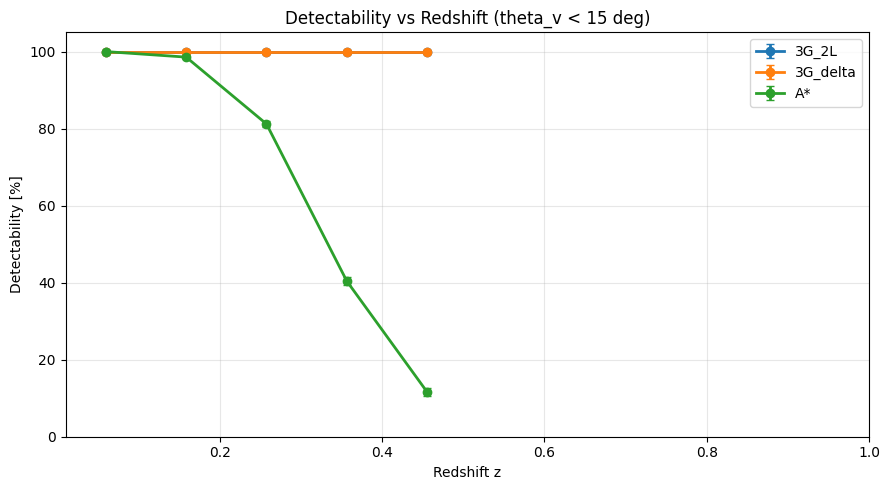

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

z_plot_edges = np.linspace(1e-2, 1.0, 11)
z_plot_centers = 0.5 * (z_plot_edges[:-1] + z_plot_edges[1:])

for combo_name, res in results_all.items():
    det_mask = res["detected"]
    frac_percent = []
    frac_err = []

    for z0, z1 in zip(z_plot_edges[:-1], z_plot_edges[1:]):
        in_bin = (redshift >= z0) & (redshift < z1)
        n_bin = int(in_bin.sum())
        if n_bin == 0:
            frac_percent.append(np.nan)
            frac_err.append(np.nan)
            continue
        n_det_bin = int((det_mask & in_bin).sum())
        p = n_det_bin / n_bin
        sigma_p = np.sqrt(p * (1 - p) / n_bin)
        frac_percent.append(100.0 * p)
        frac_err.append(100.0 * sigma_p)

    frac_percent = np.array(frac_percent)
    frac_err = np.array(frac_err)

    ax.errorbar(
        z_plot_centers,
        frac_percent,
        yerr=frac_err,
        marker="o",
        linewidth=2,
        capsize=3,
        label=combo_name,
    )

ax.set_xlabel("Redshift z")
ax.set_ylabel("Detectability [%]")
ax.set_title(f"Detectability vs Redshift (theta_v < {theta_cut_deg:.0f} deg)")
ax.set_xlim(z_plot_edges[0], z_plot_edges[-1])
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "detectability_vs_redshift.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 8. Sky-Localisation Distribution

We compare the 90 % credible sky-localisation area for detected events across
different networks. Vertical lines mark common thresholds (10, 100, 1000 deg²).

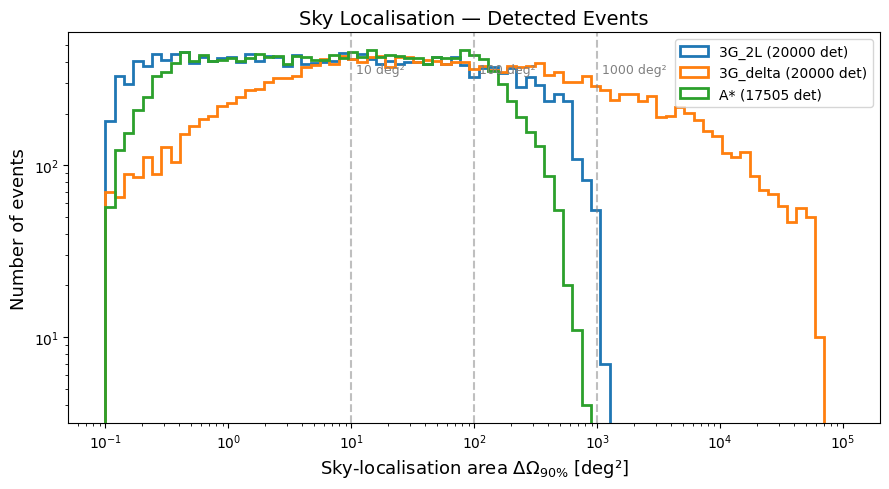

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

skyloc_bins = np.logspace(-1, 5, 80)

for combo_name, res in results_all.items():
    if res["skyloc_deg2"] is None:
        continue
    det_mask  = res["detected"]
    skyloc_ok = res["skyloc_deg2"][det_mask]
    # filter out NaN / inf
    skyloc_ok = skyloc_ok[np.isfinite(skyloc_ok) & (skyloc_ok > 0)]
    ax.hist(skyloc_ok, bins=skyloc_bins, histtype="step", linewidth=2,
            label=f"{combo_name} ({len(skyloc_ok)} det)")

for threshold in [10, 100, 1000]:
    ax.axvline(threshold, ls="--", color="gray", alpha=0.5)
    ax.text(threshold * 1.1, ax.get_ylim()[1] * 0.7,
            f"{threshold} deg²", fontsize=9, color="gray")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sky-localisation area $\\Delta\\Omega_{90\\%}$ [deg²]", fontsize=13)
ax.set_ylabel("Number of events", fontsize=13)
ax.set_title("Sky Localisation — Detected Events", fontsize=14)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(output_dir / "skyloc_distribution.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 9. Redshift vs Sky Localisation — Threshold Cuts

For each network we show how many events survive progressively tighter
sky-localisation cuts.

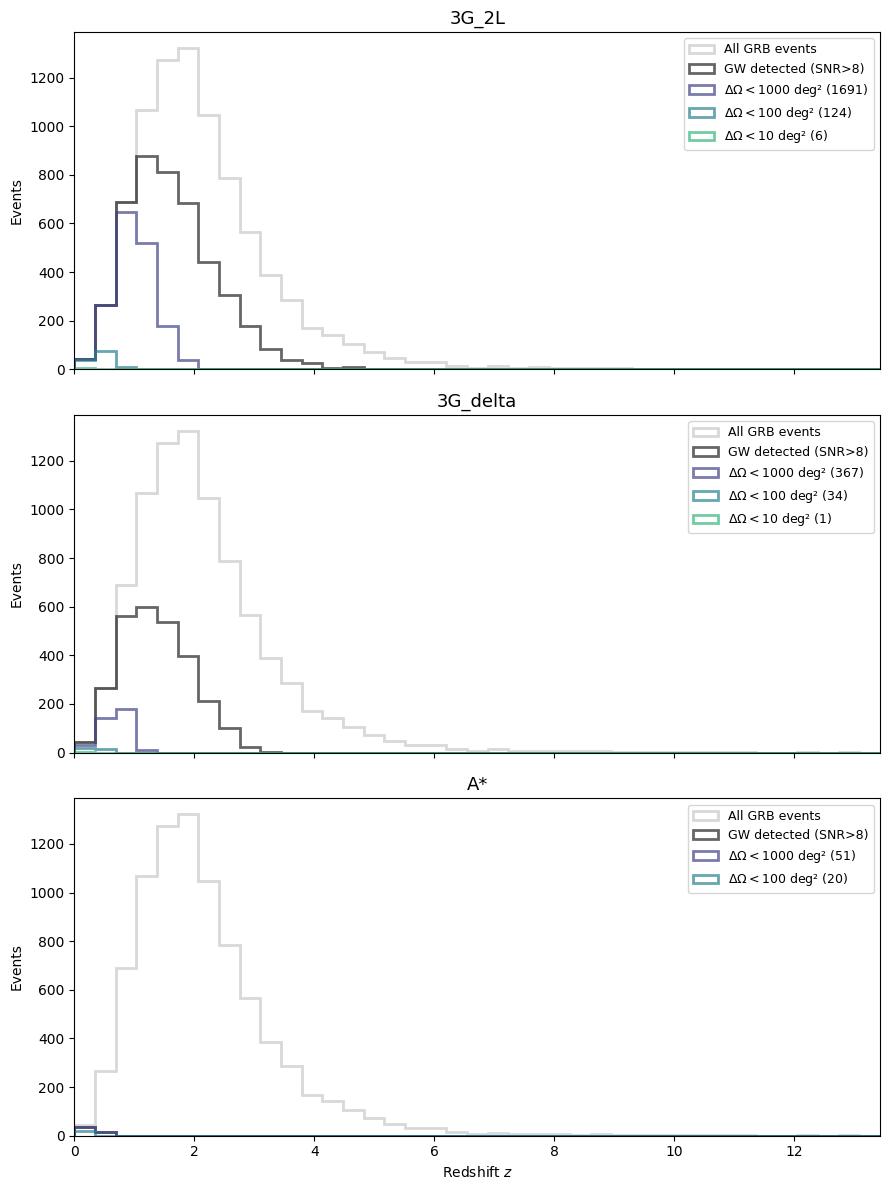

In [ ]:
skyloc_thresholds = [1000, 100, 10, 1]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(skyloc_thresholds)))

n_combos = len(combinations)
fig, axes = plt.subplots(n_combos, 1, figsize=(9, 4 * n_combos), sharex=True)
if n_combos == 1:
    axes = [axes]

bins = np.linspace(0, redshift.max() + 0.5, 40)

for ax, (combo_name, res) in zip(axes, results_all.items()):
    det_mask = res["detected"]
    skyloc   = res["skyloc_deg2"]

    ax.hist(redshift, bins=bins, color="gray", alpha=0.3,
            label="All GRB events", histtype="step", linewidth=2)
    ax.hist(redshift[det_mask], bins=bins, color="black", alpha=0.6,
            label=f"GW detected (SNR>{SNR_THRESHOLD:.0f})", histtype="step", linewidth=2)

    if skyloc is not None:
        for thr, col in zip(skyloc_thresholds, colors):
            cut = det_mask & np.isfinite(skyloc) & (skyloc <= thr)
            n_cut = int(cut.sum())
            if n_cut > 0:
                ax.hist(redshift[cut], bins=bins, color=col, alpha=0.7,
                        label=f"$\\Delta\\Omega < {thr}$ deg² ({n_cut})",
                        histtype="step", linewidth=2)

    ax.set_ylabel("Events")
    ax.set_title(combo_name, fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(0, redshift.max() + 0.5)

axes[-1].set_xlabel("Redshift $z$")
fig.tight_layout()
fig.savefig(output_dir / "redshift_skyloc_cuts.pdf", dpi=200, bbox_inches="tight")
plt.show()

## 10. Save Results

Save the augmented catalogue for each detector combination.

In [ ]:
for combo_name, res in results_all.items():
    out_df = df_params.copy()
    out_df["snr_network"] = res["snr"]
    out_df["detected"] = res["detected"]
    if res["skyloc_deg2"] is not None:
        out_df["skyloc_deg2"] = res["skyloc_deg2"]

    safe_name = combo_name.replace(" ", "_").replace("+", "and")
    out_path = output_dir / f"catalogue_{safe_name}.csv"
    out_df.to_csv(out_path, index=False)
    print(f"Saved: {out_path} ({int(res['detected'].sum())} detected)")

Saved: Output_files/tutorial4_gwfish_skyloc/catalogue_3G_2L.csv  (4463 detected)
Saved: Output_files/tutorial4_gwfish_skyloc/catalogue_3G_delta.csv  (2743 detected)
Saved: Output_files/tutorial4_gwfish_skyloc/catalogue_A*.csv  (51 detected)


---

## Summary

| What | How |
|---|---|
| **Population** | Synthetic sample in `z \in [1e-2, 1]` with 10 bins and 20 events per bin, isotropic `theta_v`, then `theta_v < 15 deg` cut |
| **Fisher matrix** | `compute_network_errors` run in parallel with `joblib.Parallel` |
| **Sky localisation** | 90 % credible area from Fisher matrix, scaled by `sky_localization_percentile_factor()` |
| **Networks tested** | `3G_2L`, `3G_delta`, `A*` |
| **Detectability product** | `% detectability vs redshift` curve for all networks + per-network output catalogues |